# Análisis Exploratorio de Datos - Sign Language MNIST

Este notebook presenta un análisis exploratorio detallado del dataset Sign Language MNIST, un conjunto de imágenes de 28×28 píxeles que representan 24 letras del alfabeto americano de señas (excluyendo J y Z por tener movimiento). 

**Objetivos de esta fase:**
- Comprender la estructura de los datos
  
- Detectar posibles problemas (desbalance, redundancia, ruido)

- Sentar las bases para la posterior fase de modelado.


## 1. Configuración inicial y carga de datos

Importamos las librerías necesarias y cargamos los archivos de entrenamiento y prueba.


In [4]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

# Auxiliary Functions
from src.data_utils import plot_statistics_grid, compare_similar_letters


%matplotlib inline


In [5]:
train = pd.read_csv("../input/sign_mnist_train.csv")
test = pd.read_csv("../input/sign_mnist_test.csv")

print("Dimensiones del conjunto de entrenamiento:", train.shape)
print("Dimensiones del conjunto de prueba:", test.shape)
train.head()

Dimensiones del conjunto de entrenamiento: (27455, 785)
Dimensiones del conjunto de prueba: (7172, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,...,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,156,158,160,163,165,159,166,168,170,170,171,171,171,172,171,171,170,170,169,111,121,129,135,141,144,148,151,154,157,160,...,205,206,206,207,207,206,206,204,205,204,203,202,142,151,160,172,196,188,188,190,135,96,86,77,77,79,176,205,207,207,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,157,158,156,154,154,153,152,151,149,149,148,147,146,144,142,143,138,92,108,158,159,159,159,160,160,160,160,160,160,160,...,100,78,120,157,168,107,99,121,133,97,95,120,135,116,95,79,69,86,139,173,200,185,175,198,124,118,94,140,133,84,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,186,185,185,185,184,184,184,181,181,179,179,179,178,178,109,52,66,77,83,188,189,189,188,188,189,188,188,188,188,187,...,203,204,203,201,200,200,199,198,196,195,194,193,198,166,132,114,89,74,79,77,74,78,132,188,210,209,206,205,204,203,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,211,209,207,208,207,206,203,202,201,200,198,197,195,192,197,171,51,52,54,212,213,215,215,212,212,213,212,212,211,211,...,247,242,233,231,230,229,227,225,223,221,220,216,58,51,49,50,57,60,17,15,18,17,19,1,159,255,237,239,237,236,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,186,188,189,189,190,191,189,190,190,187,190,192,193,191,191,192,192,194,194,166,169,172,174,177,180,182,185,186,187,190,...,90,77,88,117,123,127,129,134,145,152,156,179,105,106,105,104,104,104,175,199,178,152,136,130,136,150,118,92,85,76,92,105,105,108,133,163,157,163,164,179


Descripción de las variables

`label`: etiqueta de la letra (0 → A, 1 → B, …, 23 → Y, excluyendo J y Z).

`pixel1` … `pixel784`: valores de intensidad en escala de grises (0–255) para cada píxel de la imagen de 28×28.



## 2. Estadísticas generales


Verificamos la integridad de los datos: tipos, valores nulos y rangos.



In [6]:
train.info()
print("\nValores nulos totales:", train.isnull().sum().sum())
print("Tamaño del conjunto de entrenamiento:", train.shape)
print("Tamaño del conjunto de prueba:", test.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27455 entries, 0 to 27454
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 164.4 MB

Valores nulos totales: 0
Tamaño del conjunto de entrenamiento: (27455, 785)
Tamaño del conjunto de prueba: (7172, 785)


No se detectan valores nulos y todas las columnas son de tipo entero. El conjunto de entrenamiento contiene 27.455 muestras y el de prueba 7.172, con 785 columnas cada uno (label + 784 píxeles).



## 3. Distribución de las clases (letras)


Es importante evaluar si el dataset está balanceado, ya que un desbalance extremo podría sesgar el modelo hacia las clases mayoritarias.



### 3.1 Mapeo de etiquetas a letras


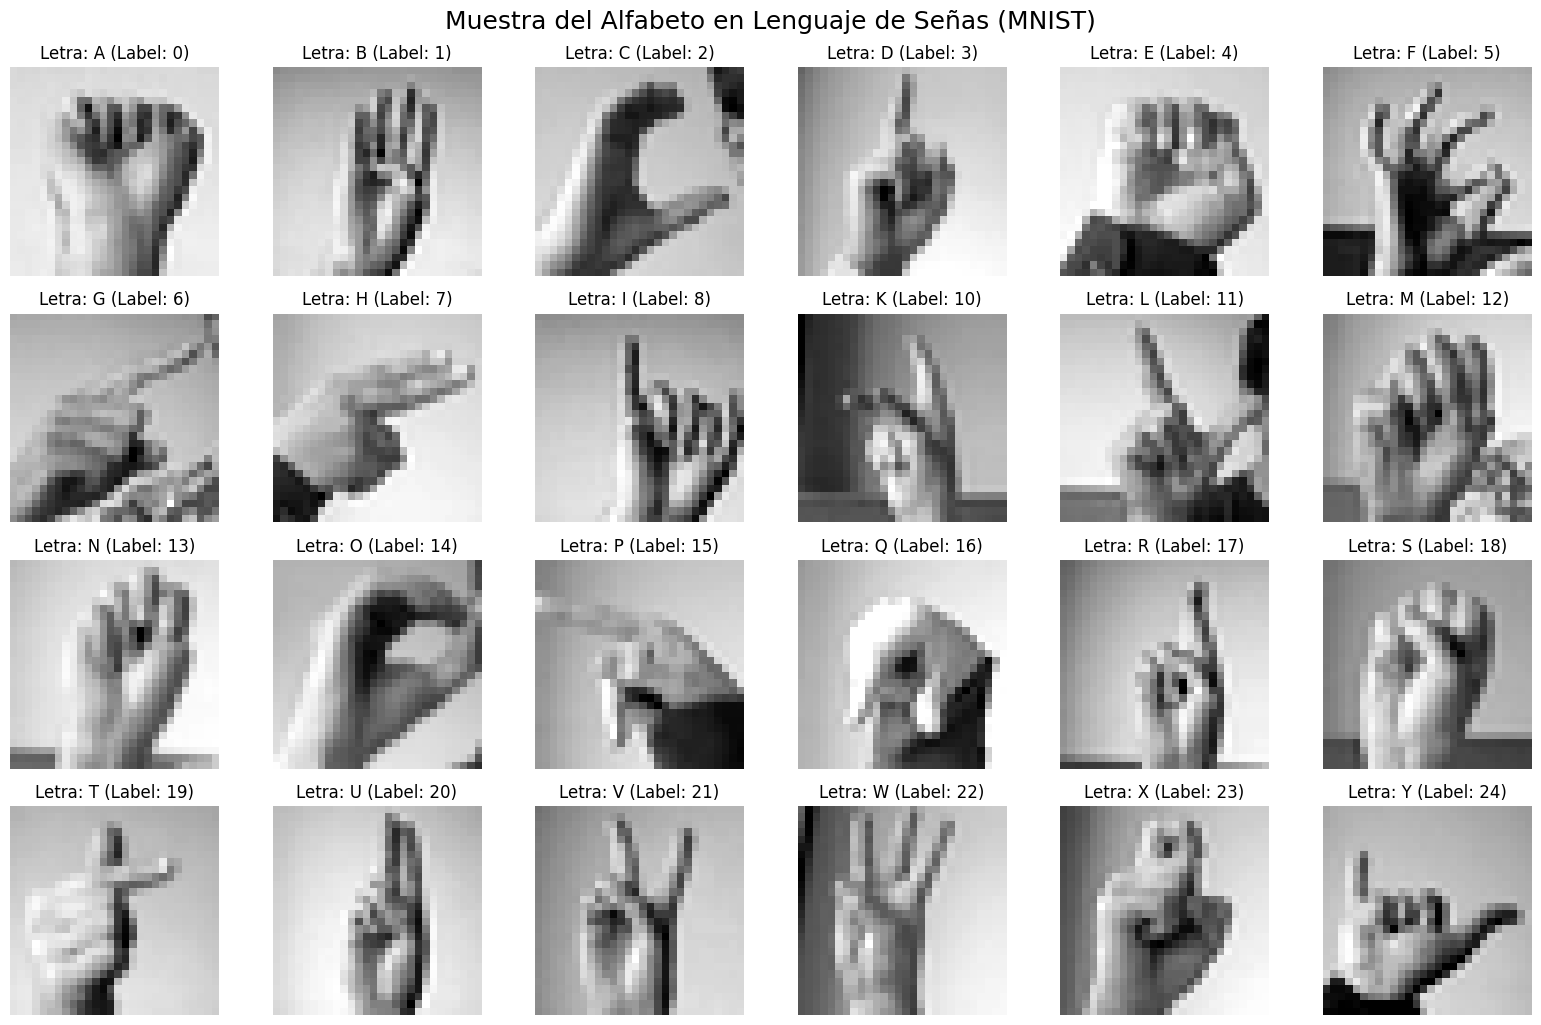

In [8]:
class_labels = [chr(i + 65) for i in range(25) if i != 9] 

plt.figure(figsize=(16, 10))

for i, letter in enumerate(class_labels):
    target_label = i if i < 9 else i + 1 # skip j
    sample = train[train['label'] == target_label].iloc[0]
    pixels = sample.drop('label').values.reshape(28, 28)

    plt.subplot(4, 6, i + 1)
    plt.imshow(pixels, cmap='gray')
    plt.title(f"Letra: {letter} (Label: {target_label})", fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.suptitle("Muestra del Alfabeto en Lenguaje de Señas (MNIST)", fontsize=18, y=1.02)
plt.show()

### 3.2 Métricas de balance


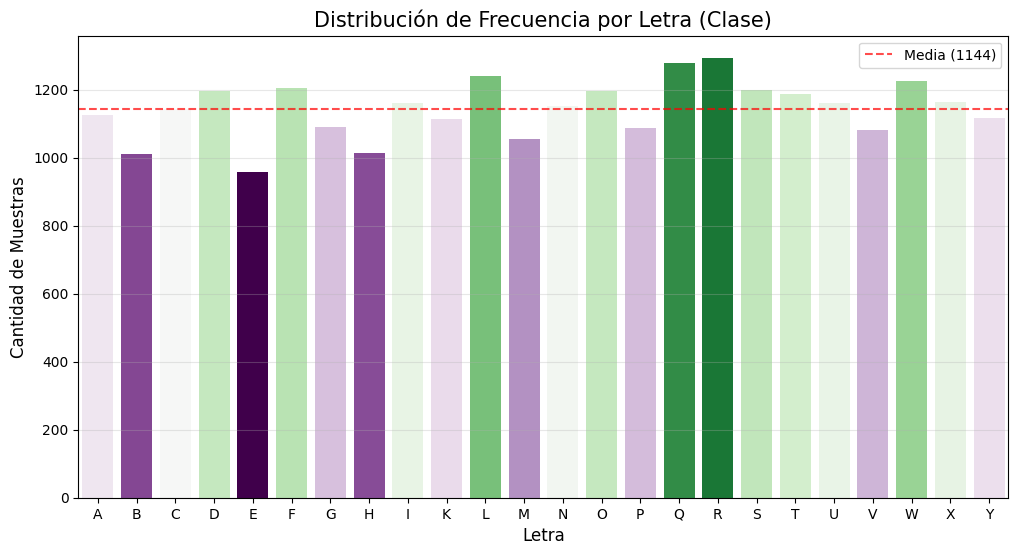

Métricas de Desbalance:
- Coeficiente de Variación (CV): 0.0732
- Razón de desbalance (IR): 1.3521


In [16]:
full_labels_map = { (i if i < 9 else i + 1): letter for i, letter in enumerate(class_labels) }

# Calculate imbalance metrics
class_counts = train["label"].value_counts().sort_index()
n_clases = len(class_counts)
mean_samples = class_counts.mean()
std_samples = class_counts.std()

#-- Coefficient of Variation (CV)
cv_score = std_samples / mean_samples

#-- Imbalance Ratio (IR)
imbalance_ratio = class_counts.max() / class_counts.min()

# Visualization
plt.figure(figsize=(12, 6))

# Mapping labels to letters for the plot using our map
plot_data = train["label"].map(full_labels_map)

# Use class_labels as the order to ensure J is skipped and sequence is A-Y
ax = sns.countplot(x=plot_data, order=class_labels, hue=plot_data, legend=False)

# Purple-green palette according to distance from the mean
cmap = plt.get_cmap("PRGn")
max_dev = max(class_counts.max() - mean_samples, mean_samples - class_counts.min())
norm = plt.Normalize(vmin=mean_samples - max_dev, vmax=mean_samples + max_dev)

for patch in ax.patches:
    val = patch.get_height()
    # Handle possible None values if a bar is empty
    if val > 0:
        patch.set_facecolor(cmap(norm(val)))

# Ideal balance reference line
plt.axhline(mean_samples, color='red', linestyle='--', alpha=0.7, label=f'Media ({mean_samples:.0f})')

plt.title("Distribución de Frecuencia por Letra (Clase)", fontsize=15)
plt.xlabel("Letra", fontsize=12)
plt.ylabel("Cantidad de Muestras", fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Métricas de Desbalance:")
print(f"- Coeficiente de Variación (CV): {cv_score:.4f}")
print(f"- Razón de desbalance (IR): {imbalance_ratio:.4f}")

Interpretación

- El coeficiente de variación (CV ≈ 0.07) indica una dispersión muy baja alrededor de la media.

- La razón de desbalance (IR ≈ 1.35) es moderada: la clase más frecuente (R) tiene solo un 35% más muestras que la menos frecuente (E).

- Aunque no es un desbalance crítico, convendrá monitorear el rendimiento por clase durante el modelado, especialmente para aquellas con menor representación.

## 4. Integridad de los píxeles


Analizamos las características de los valores de píxeles en todo el conjunto.



In [12]:
pixel_data = train.drop('label', axis=1)

# Checking for Constant Pixels (Zero Variance)
# These pixels have the same value for every single image in the dataset
constant_pixels = pixel_data.columns[pixel_data.nunique() <= 1]
n_constant = len(constant_pixels)

# Range Validation
min_pixel = pixel_data.values.min()
max_pixel = pixel_data.values.max()

# Statistical Summary of pixel intensities
pixel_mean = pixel_data.values.mean()
pixel_std = pixel_data.values.std()

print(f"Reporte de integridad:")
print(f"- Píxeles constantes: {n_constant}")
print(f"- Rango de valores: [{min_pixel}, {max_pixel}]")
print(f"- Intensidad media global: {pixel_mean:.2f}")
print(f"- Desviación estándar global: {pixel_std:.2f}")

Reporte de integridad:
- Píxeles constantes: 0
- Rango de valores: [0, 255]
- Intensidad media global: 159.29
- Desviación estándar global: 48.77


Todos los píxeles presentan variabilidad (ninguno es constante). Los valores se encuentran en el rango esperado $[0, 255]$ y la intensidad media es moderada ($\approx 159$), con una desviación típica de $\approx49$.



## 5. Análisis espacial: imagen promedio y mapa de varianza por clase


Para entender qué regiones de la imagen son realmente informativas, calculamos la media y la desviación estándar píxel a píxel para cada letra.



In [13]:
grouped_data = train.groupby('label')
mean_pixels = grouped_data.mean()
std_pixels = grouped_data.std()


### 5.1 Imagen promedio por clase


La imagen promedio muestra la proyección visual del centroide en el espacio original. Podemos pensarla como una "imagen ideal" representativa de la clase.




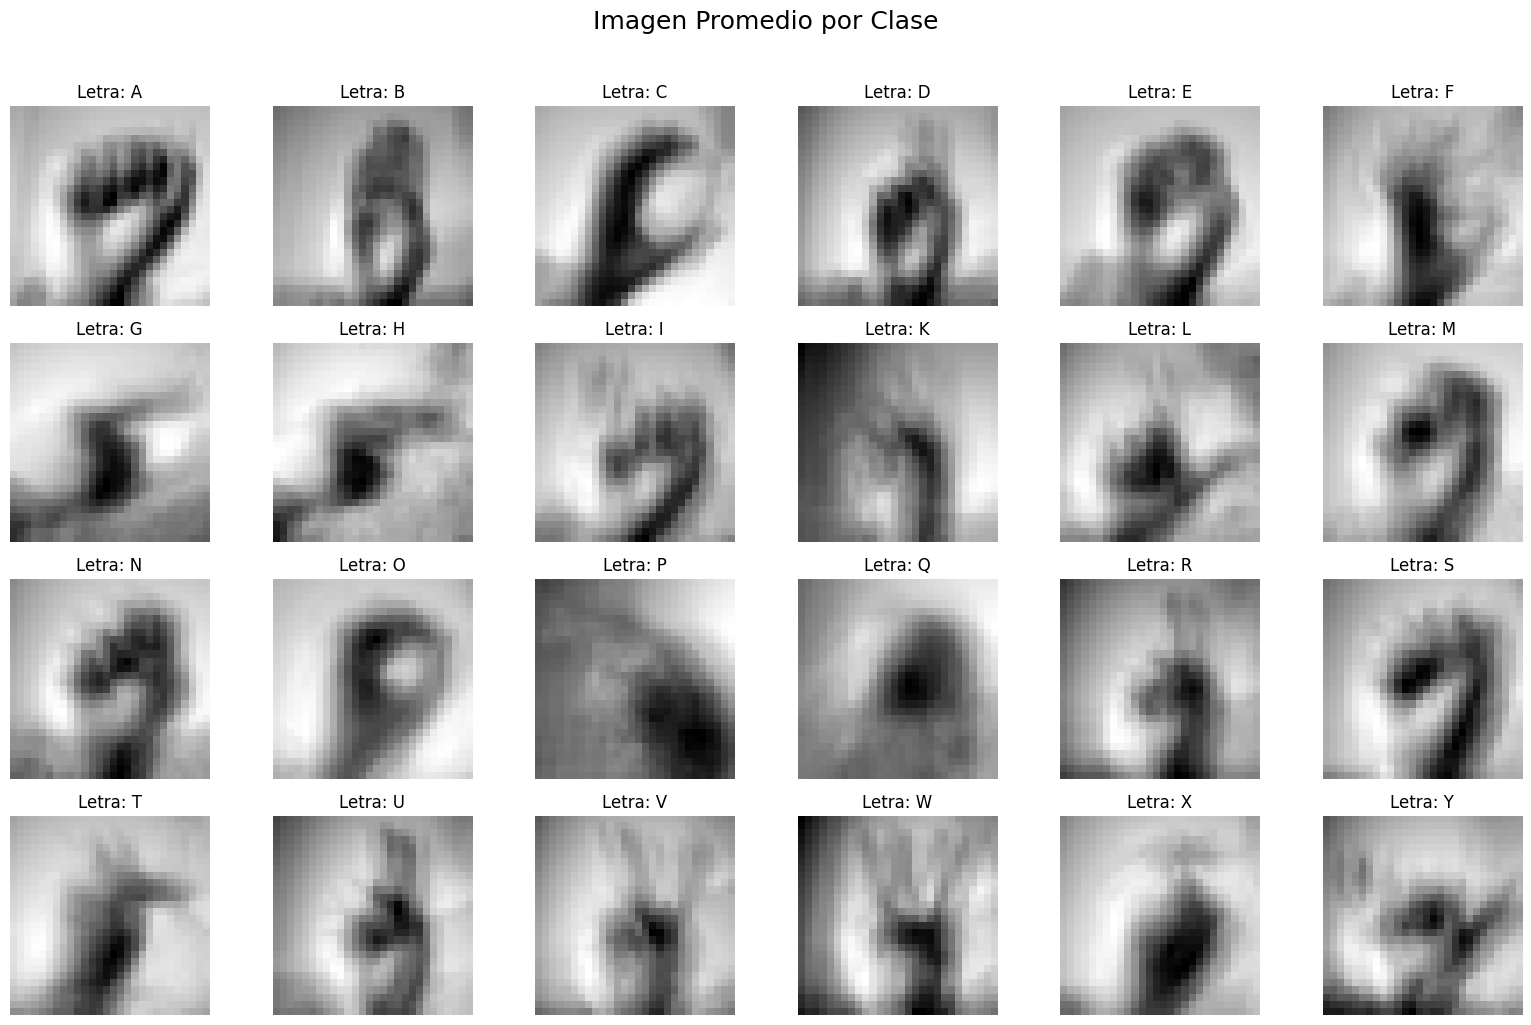

In [17]:
plot_statistics_grid(mean_pixels, full_labels_map, "Imagen Promedio por Clase", cmap='gray')


Las imágenes promedio son nítidas, lo que indica que el dataset está bien estandarizado.

### 5.2 Mapa de desviación estándar


Los píxeles con alta variabilidad dentro de una misma clase indican zonas donde los gestos difieren (por ejemplo, posición de los dedos, rotaciones leves). El fondo debería tener varianza casi nula.



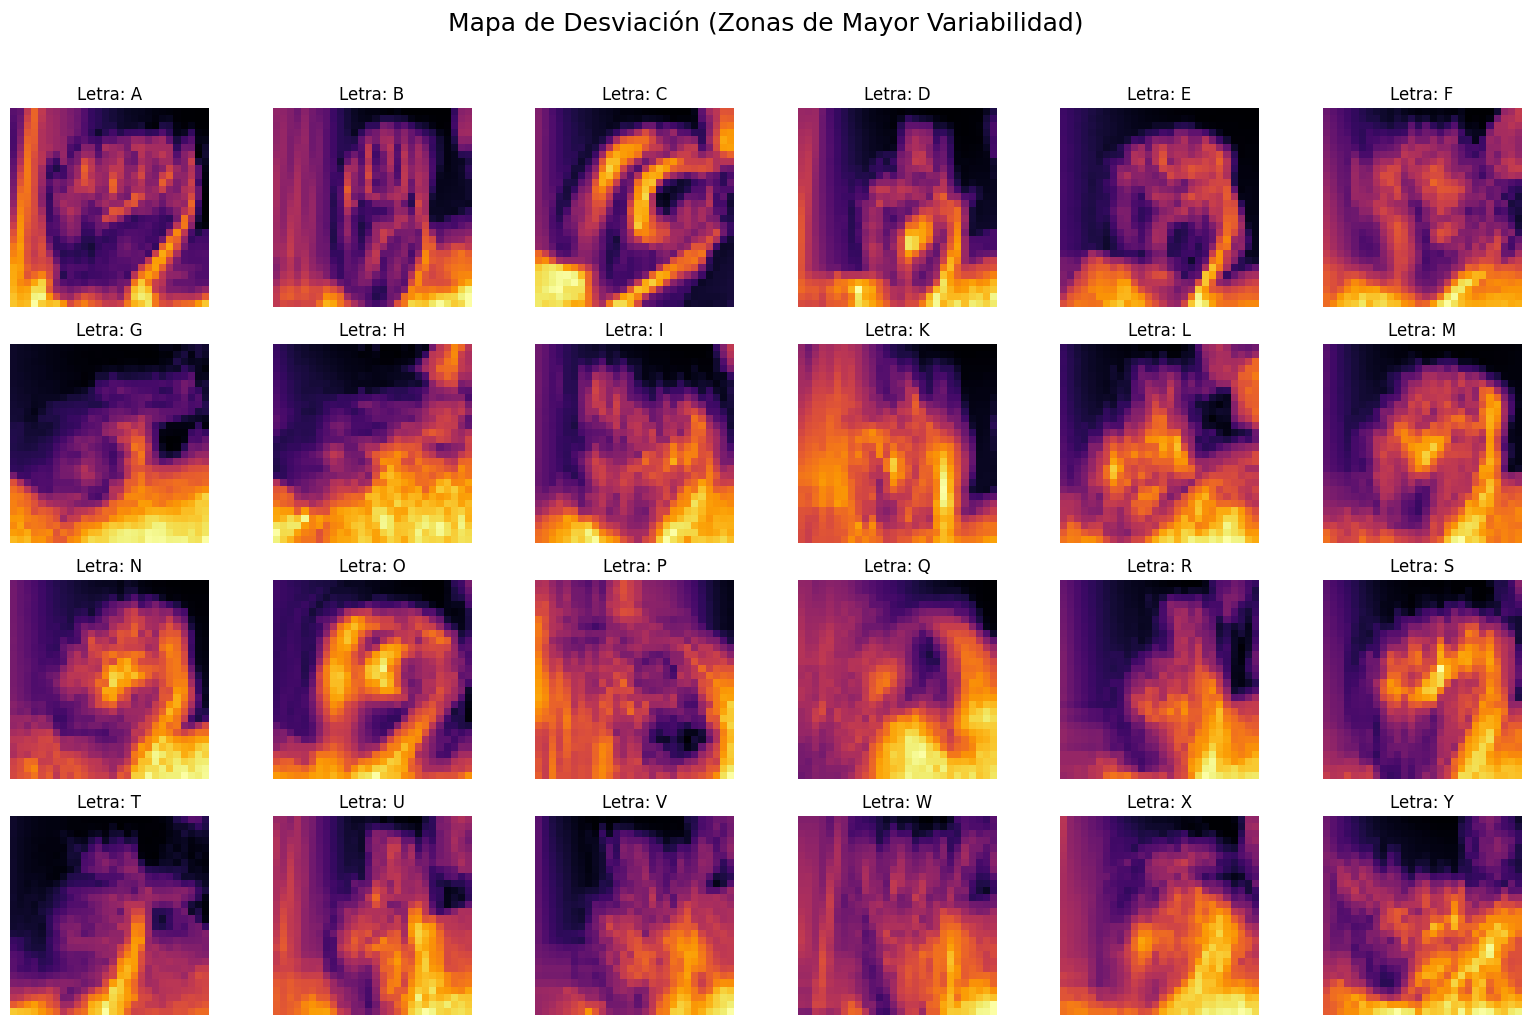

In [18]:
plot_statistics_grid(std_pixels, full_labels_map, "Mapa de Desviación (Zonas de Mayor Variabilidad)", cmap='inferno')

Los mapas de desviación muestran que las mayores variaciones (colores más brillantes) se concentran en los dedos y contornos de la mano, mientras que el fondo es prácticamente constante.

## 6. Comparación de letras visualmente similares


Algunas letras (como M y N, o G y H) son gestualmente muy parecidas. Analizamos la diferencia absoluta (píxel a píxel) entre sus imágenes promedio para identificar las regiones que realmente las distinguen.



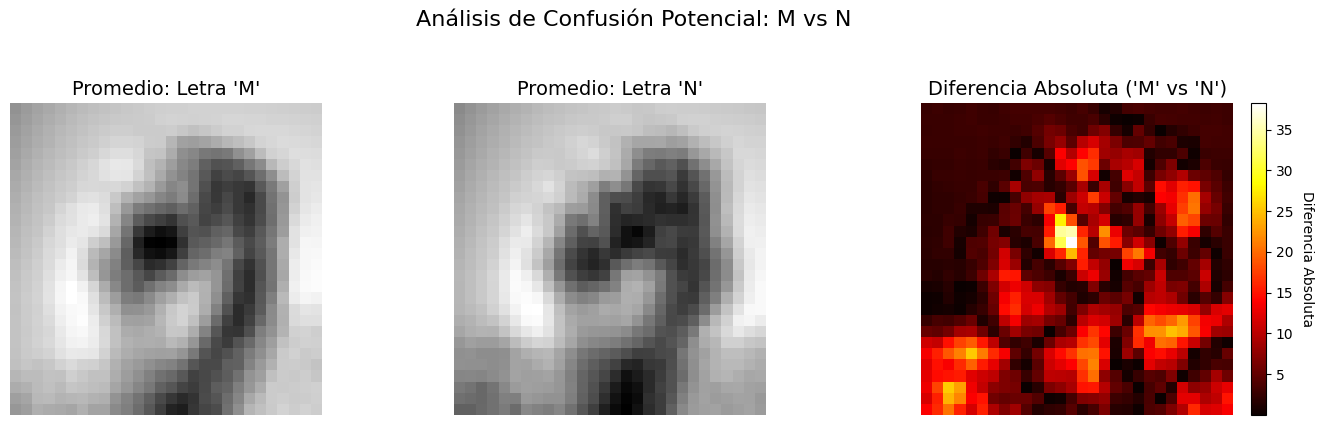

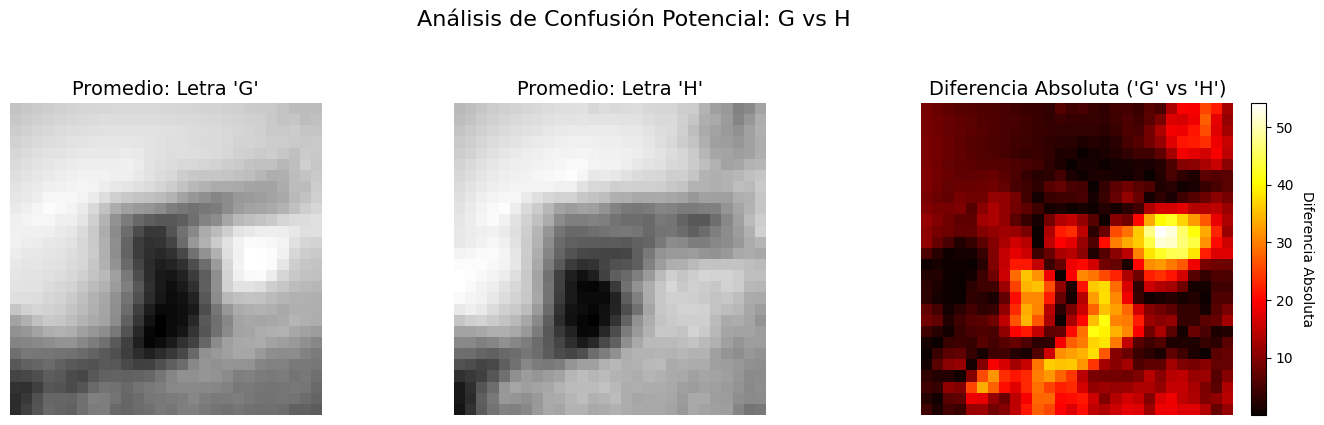

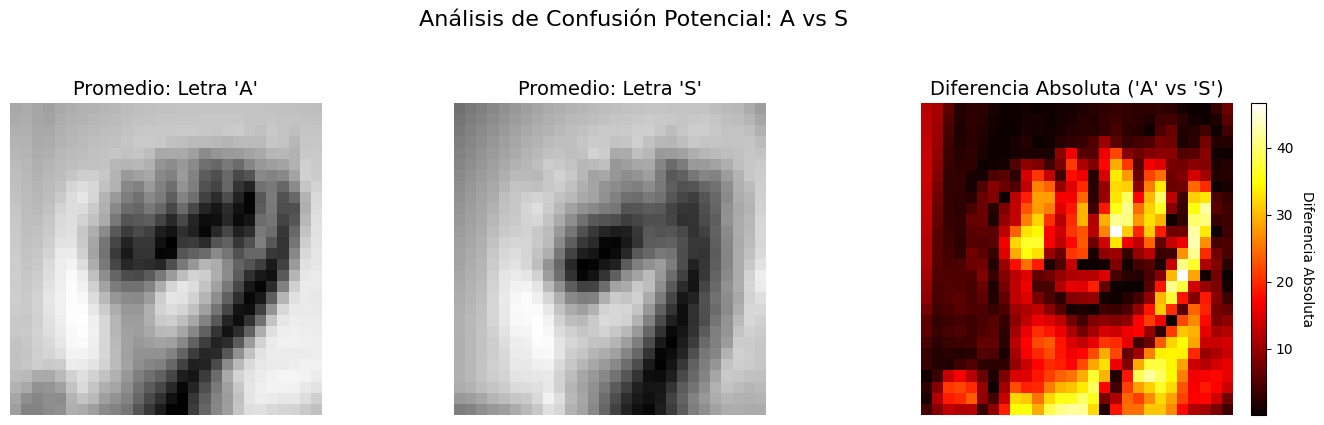

In [19]:
# Comparar pares de letras con alta similitud gestual
compare_similar_letters('M', 'N', mean_pixels, full_labels_map, title='Análisis de Confusión Potencial: M vs N')
compare_similar_letters('G', 'H', mean_pixels, full_labels_map, title='Análisis de Confusión Potencial: G vs H')
compare_similar_letters('A', 'S', mean_pixels, full_labels_map, title='Análisis de Confusión Potencial: A vs S')

Los mapas de diferencia revelan que la mayoría de los píxeles son casi idénticos entre clases (fondo, palma), y solo pequeñas regiones (generalmente la posición de dedos específicos) contienen la señal discriminante. Esto sugiere la necesidad de reducir la dimensionalidad para evitar que el modelo se enfoque en ruido o zonas irrelevantes.

## 7. Reducción de dimensionalidad con PCA


Las gráficas demuestran empíricamente que la mayor parte de la varianza estructural puede representarse en un subespacio de menor dimensión para diferenciar estas señas. La información discriminante está contenida en varianzas muy específicas.

### 7.1 Escalado previo


PCA es sensible a la escala de las variables; normalizamos los píxeles al rango $[0, 1]$.



In [20]:
X = train.drop('label', axis=1)
y = train['label']

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

### 7.2 Varianza explicada acumulada


Ajustamos PCA sin reducir para determinar cuántos componentes son necesarios para retener un 90% y 95% de la varianza.



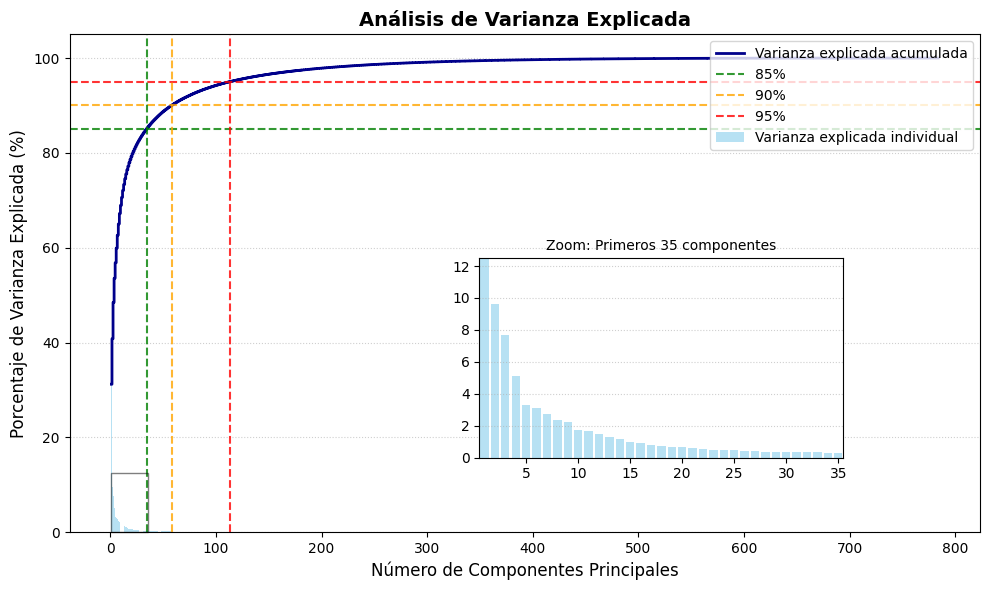

Resultados del Análisis:
- Para retener el 85% de la información necesitamos: 35 componentes.
- Para retener el 90% de la información necesitamos: 58 componentes.
- Para retener el 95% de la información necesitamos: 113 componentes.


In [21]:
pca = PCA()
pca.fit(X_scaled)

# Data Preparation
components = np.arange(1, len(pca.explained_variance_ratio_) + 1)
individual_variance = pca.explained_variance_ratio_ * 100
cumulative_variance = np.cumsum(individual_variance)

# Calculating a range of optimal components automatically
n_85 = np.argmax(cumulative_variance >= 85) + 1
n_90 = np.argmax(cumulative_variance >= 90) + 1
n_95 = np.argmax(cumulative_variance >= 95) + 1

# Using fig, ax to enable the inset zoom
fig, ax = plt.subplots(figsize=(10, 6), dpi=100)

# Plotting individual variance as bars
ax.bar(components, individual_variance, alpha=0.6, 
        label='Varianza explicada individual', color='skyblue')

# Plotting cumulative variance as a step plot
ax.step(components, cumulative_variance, where='mid', 
         label='Varianza explicada acumulada', color='darkblue', linewidth=2)

# Threshold Reference
ax.axhline(y=85, color='green', linestyle='--', alpha=0.8, label='85% ')
ax.axhline(y=90, color='orange', linestyle='--', alpha=0.8, label='90% ')
ax.axhline(y=95, color='red', linestyle='--', alpha=0.8, label='95% ')
ax.axvline(x=n_85, color='green', linestyle='--', alpha=0.8)
ax.axvline(x=n_90, color='orange', linestyle='--', alpha=0.8)
ax.axvline(x=n_95, color='red', linestyle='--', alpha=0.8)

# --- ZOOM CODE ---
# [x, y, width, height] in relative figure coordinates (0 to 1)
axins = ax.inset_axes([0.45, 0.15, 0.4, 0.4]) 
axins.bar(components[:35], individual_variance[:35], alpha=0.6, color='skyblue')
axins.step(components[:35], cumulative_variance[:35], where='mid', color='darkblue', linewidth=2)

# Zoom visual configuration
axins.set_xlim(0.5, 35.5)
# Focus the Y-axis entirely on the bars' magnitude
axins.set_ylim(0, max(individual_variance[:15])*0.4) 
axins.set_title('Zoom: Primeros 35 componentes', fontsize=10)
axins.grid(axis='y', linestyle=':', alpha=0.6)

# Draw the box and lines connecting the inset to the main plot
ax.indicate_inset_zoom(axins, edgecolor="black")
# --- END OF ZOOM CODE ---

# Style
ax.set_title('Análisis de Varianza Explicada', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de Componentes Principales', fontsize=12)
ax.set_ylabel('Porcentaje de Varianza Explicada (%)', fontsize=12)
ax.legend(loc='upper right')
ax.grid(axis='y', linestyle=':', alpha=0.6)

# Rendering
plt.tight_layout()
plt.show()

print(f"Resultados del Análisis:")
print(f"- Para retener el 85% de la información necesitamos: {n_85} componentes.")
print(f"- Para retener el 90% de la información necesitamos: {n_90} componentes.")
print(f"- Para retener el 95% de la información necesitamos: {n_95} componentes.")

Se observa que las primeras componentes concentran una proporción significativa de la varianza total, mientras que la contribución decrece rápidamente a medida que aumenta el índice de la componente. En particular, a partir de aproximadamente la componente 16, la varianza explicada individual cae por debajo del 1%. Esto indica que, aunque las componentes posteriores siguen contribuyendo a la varianza acumulada total, cada una aporta información marginal de manera individual. 

Este resultado sugiere que:

- Las primeras componentes capturan la estructura global de las imágenes (forma general de la mano).

- Las componentes intermedias capturan variaciones más finas entre clases.

- Las componentes de orden superior aportan ajustes más específicos que, aunque pequeños individualmente, contribuyen colectivamente a alcanzar altos niveles de varianza explicada.



### 7.3 Eigensigns: interpretación de las componentes


Las componentes principales pueden visualizarse como imágenes de 28×28 (autovectores). Cada una representa un patrón de variación.



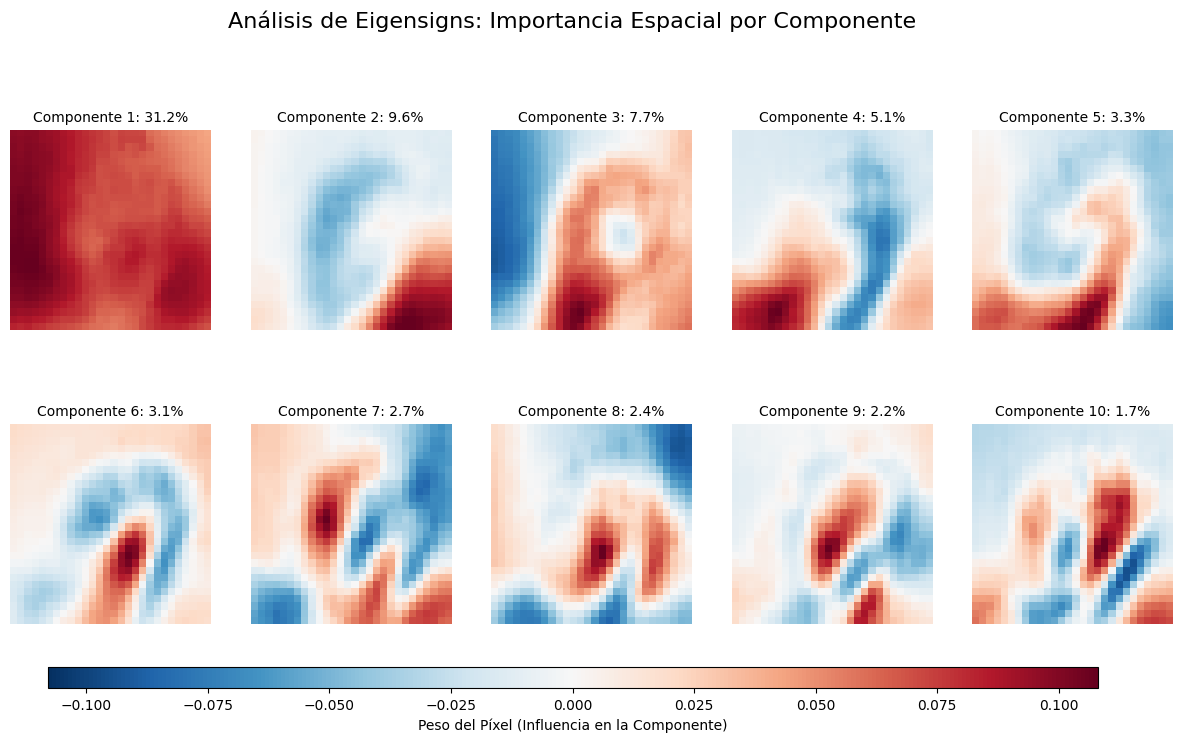

In [22]:
# Re-fitting PCA with the decided number of components
n_components = 113
pca = PCA(n_components=n_components, whiten=False)
X_pca = pca.fit_transform(X_scaled)

# Plotting the first 10 Principal Components (Eigensigns)
plt.figure(figsize=(15, 7))
for i in range(10):
    eigen_sign = pca.components_[i].reshape(28, 28)
    ax = plt.subplot(2, 5, i + 1)

    v_max = np.max(np.abs(eigen_sign))
    im = ax.imshow(eigen_sign, cmap='RdBu_r', vmin=-v_max, vmax=v_max)

    plt.title(f"Componente {i+1}: {pca.explained_variance_ratio_[i]*100:.1f}%", fontsize=10)
    plt.axis('off')

cax = plt.axes([0.15, 0.05, 0.7, 0.03])
plt.colorbar(im, cax=cax, orientation='horizontal', label='Peso del Píxel (Influencia en la Componente)')
plt.suptitle("Análisis de Eigensigns: Importancia Espacial por Componente", fontsize=16, y=1.02)
plt.show()

El color en los mapas de calor representa la magnitud de la coordenada del autovector en cada píxel $p$, conocida como **loading** ($w_{i,p}$).

- **Zonas Saturadas (Rojo/Azul)**: Señalan los píxeles con mayor peso en la definición del eje. Indican qué regiones de la imagen son "sensibles" a esta componente.
- **Zonas Neutras (Blanco)**: Representan píxeles con carga cercana a cero. Son regiones ortogonales a la componente que el PCA ha identificado como redundantes o carentes de varianza relevante para ese eje específico.
- **Polaridad (Positivo vs. Negativo)**: La diferencia de signos dentro de un mismo autovector establece una relación de contraste. Píxeles del mismo color varían en fase (correlación). Píxeles de colores opuestos varían de forma inversa (anticorrelación). Esto permite que una sola componente actúe como un detector diferencial, identificando, por ejemplo, si un dedo está extendido (positivo) o contraído (negativo) respecto al promedio.

El análisis visual confirma la jerarquía de la información: mientras que las primeras componentes describen la geometría básica de la mano, las componentes superiores (como la 8 o la 10) actúan como filtros especializados en morfología diferencial.


### 7.4 Proyección en 2D y separabilidad


Proyectamos todas las muestras en el plano de las dos primeras componentes para inspeccionar visualmente la separación entre clases.



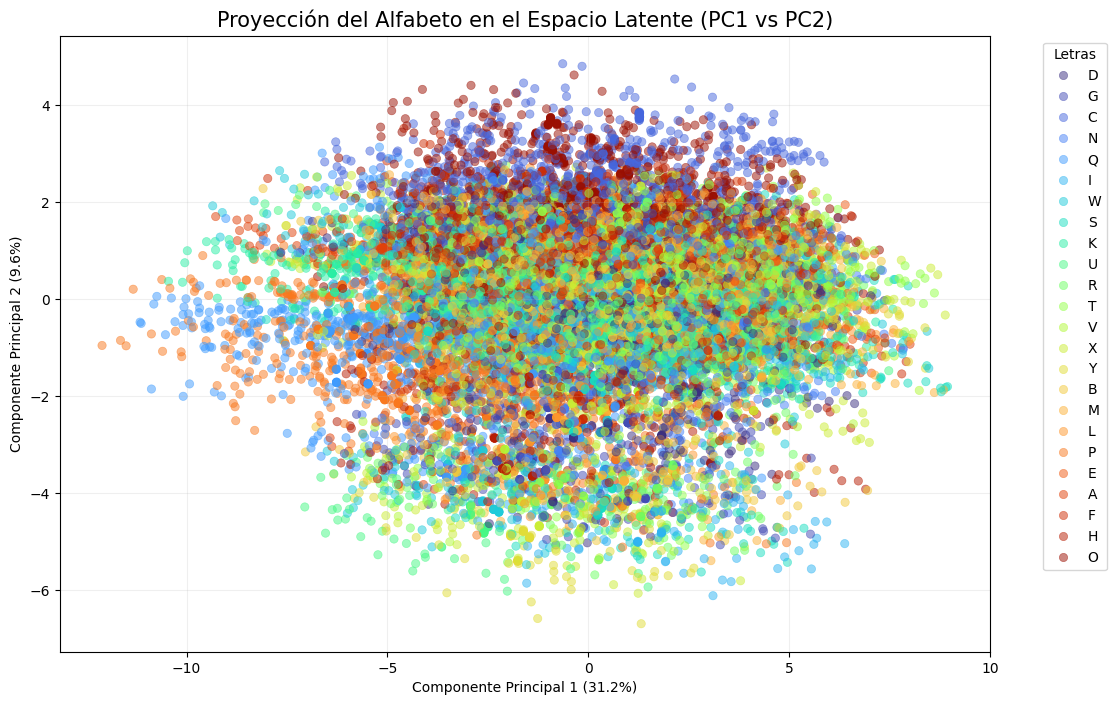

In [24]:
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=y.map(full_labels_map),
    palette="turbo",
    alpha=0.5,
    edgecolor=None
)

plt.title("Proyección del Alfabeto en el Espacio Latente (PC1 vs PC2)", fontsize=15)
plt.xlabel(f"Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Letras")
plt.grid(alpha=0.2)
plt.show()

El gráfico presenta un solapamiento masivo de las letras en sus primeras dos dimensiones.

La $PC_1$ (31.2%) y la $PC_2$ (9.6%) capturan solo el **40.8%** de la variabilidad total. Esto significa que más de la mitad de la información crítica para distinguir las señas está "oculta" en las dimensiones superiores.

El solapamiento central refleja la realidad gestual: muchas letras comparten una base común (la palma y el brazo) y solo se diferencian por movimientos de los dedos que estas componentes globales no logran aislar por completo. Especialmente las letras M y N.



## 8. Validación de la reconstrucción


Tras obtener que las 113 Componentes Principales explican el 95% de la varianza, surge una pregunta fundamental:

¿Esta compresión masiva (de 784 a 113 dimensiones) sacrifica los rasgos morfológicos sutiles que distinguen letras visualmente similares, como la 'M' de la 'N'?

Para asegurarnos de que esta compresión no degrada la información semántica, reconstruimos algunas imágenes desde el espacio latente y comparamos con las originales.

### 8.1 Reconstrucción de muestras individuales


Tomamos un ejemplo de la letra 'M' y otro de la 'N' (clases críticamente similares).



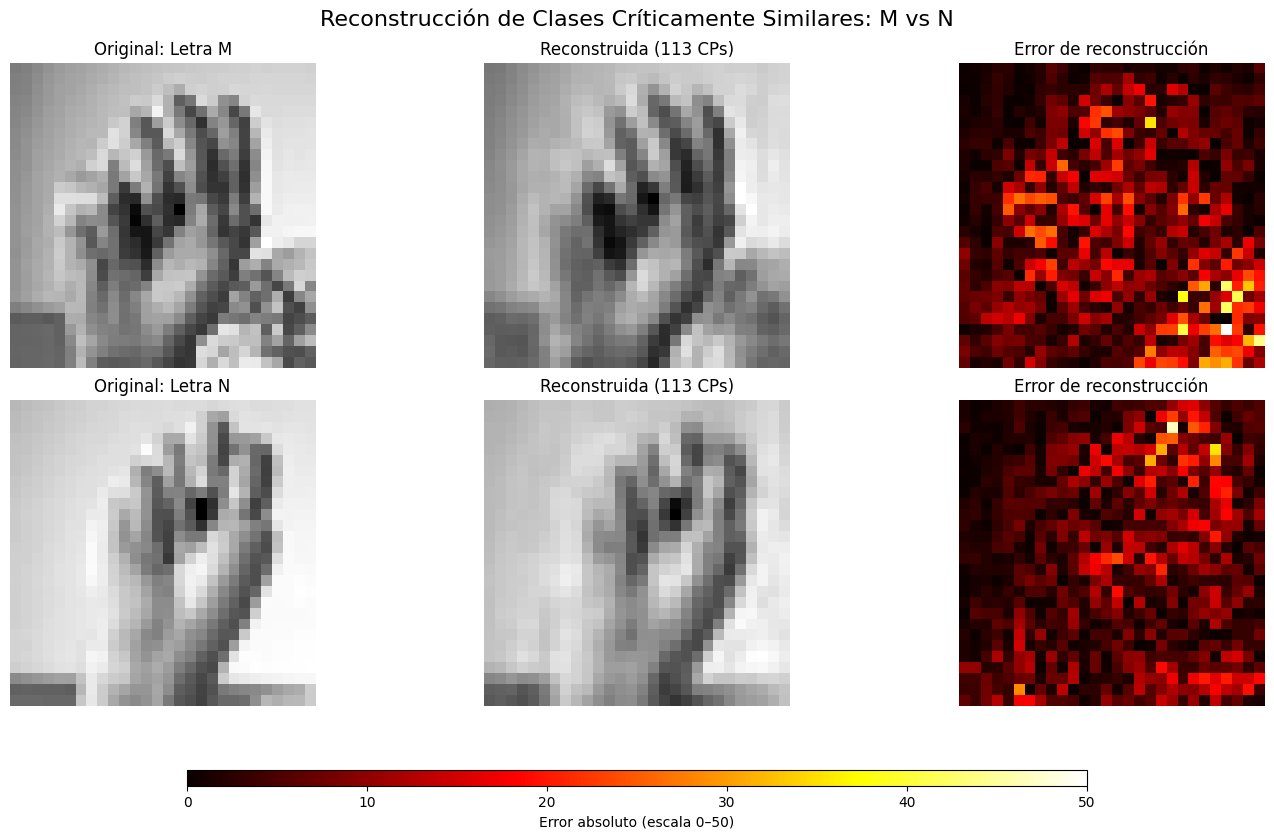

In [25]:
target_labels = [12, 13]  # M y N
letters_to_plot = ['M', 'N']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

errores = []
for row, (label, letter) in enumerate(zip(target_labels, letters_to_plot)):
    target_idx = train[train['label'] == label].index[0]
    original_img = X.iloc[target_idx].values.reshape(28, 28)
    projected_img = X_pca[target_idx].reshape(1, -1)
    reconstructed_scaled = pca.inverse_transform(projected_img)
    reconstructed_unscaled = scaler.inverse_transform(reconstructed_scaled)
    reconstructed_img = reconstructed_unscaled.reshape(28, 28)
    error = np.abs(original_img - reconstructed_img)
    errores.append(error)

    axes[row, 0].imshow(original_img, cmap='gray')
    axes[row, 0].set_title(f'Original: Letra {letter}', fontsize=12)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(reconstructed_img, cmap='gray')
    axes[row, 1].set_title('Reconstruida (113 CPs)', fontsize=12)
    axes[row, 1].axis('off')

    im = axes[row, 2].imshow(error, cmap='hot', vmin=0, vmax=50)
    axes[row, 2].set_title('Error de reconstrucción', fontsize=12)
    axes[row, 2].axis('off')

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
cbar_ax = fig.add_axes([0.2, 0.05, 0.6, 0.02])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Error absoluto (escala 0–50)', fontsize=10)

plt.suptitle('Reconstrucción de Clases Críticamente Similares: M vs N',
             fontsize=16, y=1.02)
plt.show()

**Observaciones**

- Las imágenes reconstruidas conservan perfectamente la identidad de la letra y los rasgos distintivos.

- Los errores más altos se concentran en texturas de alta frecuencia o sombreados, no en la forma de la mano.

- El PCA prioriza direcciones de alta varianza global, lo que tiende a suavizar variaciones locales que no contribuyen significativamente a la estructura dominante del dataset.

### 8.2 Reconstrucción de las imágenes promedio


Tras validar la reconstrucción individual, procedemos a un análisis más robusto: comparar las imágenes promedio reconstruidas de las clases 'M' y 'N'. Este análisis responde a la pregunta: *¿La información que diferencia a estas dos clases tan similares sigue siendo nítida y localizada después de la compresión?*


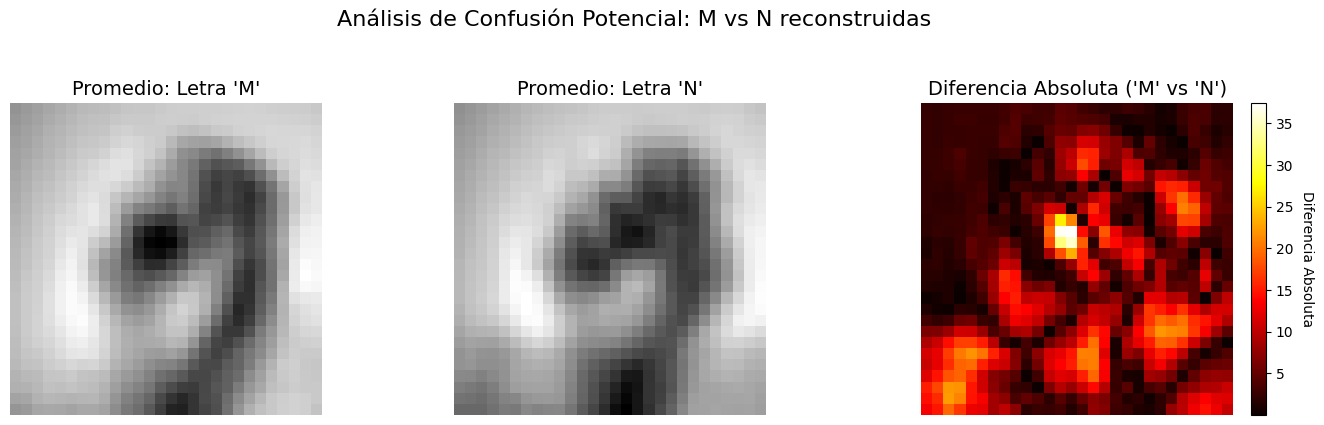

In [27]:
X_reconstructed_scaled = pca.inverse_transform(X_pca)
X_reconstructed = scaler.inverse_transform(X_reconstructed_scaled)

reconstructed_df = pd.DataFrame(X_reconstructed, columns=X.columns)
reconstructed_df['label'] = train['label'].values

mean_reconstructed = reconstructed_df.groupby('label').mean()
std_reconstructed  = reconstructed_df.groupby('label').std()

compare_similar_letters('M', 'N', mean_reconstructed, full_labels_map, title = 'Análisis de Confusión Potencial: M vs N reconstruidas')

El mapa de diferencia absoluta entre las medias reconstruidas es casi idéntico al obtenido con los datos originales (Ver sección 6), e incluso más limpio (menos ruido de fondo). Esto sugiere que, globalmente, las 113 componentes retienen la información morfológica esencial y que la reducción no solo es segura, sino beneficiosa.

## 9. Conclusiones y hoja de ruta para modelado


El análisis exploratorio permitió caracterizar en profundidad el dataset Sign Language MNIST e identificar propiedades relevantes para la etapa de modelado. Los hallazgos principales son los siguientes:

- **Balance aceptable por clase** : El desbalance observado es moderado (IR $\approx$ 1.35, CV $\approx$ 0.07), lo que indica una distribución relativamente homogénea de muestras por clase. Desde una perspectiva de modelado:

    - No parece necesario aplicar técnicas de remuestreo en una primera instancia.

    - Se evita introducir complejidad adicional en el pipeline.

    - El foco puede mantenerse en capacidad discriminativa del modelo.

    No obstante, el rendimiento será monitoreado por clase para detectar posibles asimetrías en métricas como recall o F1-score.

- **Alta Redundancia Espacial**: El análisis de varianza intra e inter-clase sugiere que la variabilidad más relevante se concentra en regiones específicas de las imágenes, principalmente asociadas a configuraciones de los dedos. En contraste, una proporción considerable de los 784 píxeles corresponde a:

    - Fondo relativamente estático.

    - Regiones con baja variabilidad.

    - Zonas con alta correlación espacial.

Esto sugiere la presencia de redundancia en el espacio original, lo cual puede incrementar tanto el costo computacional como el riesgo de sobreajuste si se modela directamente sobre los píxeles. En este contexto, la reducción de dimensionalidad aparece como una estrategia prometedora para disminuir redundancia y mejorar la eficiencia del modelado.

- **PCA como compresión estructural**:
El análisis espectral muestra que aproximadamente 113 componentes principales son necesarias para retener el 95% de la varianza total. Este umbral se utiliza comúnmente como criterio práctico para equilibrar compresión y preservación de información.

El análisis de varianza explicada individual muestra además que las primeras componentes concentran una proporción significativa de la varianza total, mientras que a partir de aproximadamente la componente 16 cada componente individual explica menos del 1% de la varianza. Esto indica que la información se distribuye de manera progresivamente más fragmentada entre componentes de orden superior.

Las reconstrucciones a partir de componentes principales sugieren que:

- La morfología general de las letras se preserva.

- Las variaciones globales entre clases se mantienen.

- Parte del ruido de fondo y variaciones de iluminación se atenúan.

En este sentido, PCA actúa como una herramienta de reducción dimensional que puede funcionar también como mecanismo de regularización al reducir la dimensionalidad efectiva del espacio de entrada. Además, puede mejorar la relación señal-ruido si el ruido se encuentra principalmente en componentes de baja varianza.

*Nota metodológica sobre fuga de información (data leakage)*:
El ajuste de PCA y el escalado realizados durante el EDA tuvieron únicamente un propósito exploratorio. Aplicar estas transformaciones sobre el dataset completo antes de la partición introduciría fuga de información desde los datos de validación hacia el modelo. Por este motivo, en la fase de modelado estas transformaciones se ajustarán exclusivamente sobre los datos de entrenamiento dentro de cada partición de validación cruzada.

- **Separabilidad no trivial en baja dimensión**:
La proyección de los datos sobre las dos primeras componentes principales (que explican aproximadamente el 40.8% de la varianza total) muestra un solapamiento significativo entre clases. Esto indica que:

- Las proyecciones en baja dimensión no permiten una separación clara entre clases.

- Parte de la información discriminante podría encontrarse en componentes de orden superior.

- La estructura relevante del dataset es inherentemente multivariada.

En consecuencia, la etapa de modelado requerirá algoritmos capaces de capturar relaciones no lineales o estructuras complejas dentro del subespacio generado por PCA.


#### Estrategia propuesta para la fase de modelado

A partir de los hallazgos del análisis exploratorio, la fase de modelado se enfocará en evaluar clasificadores capaces de capturar relaciones no lineales en un espacio de dimensionalidad reducida mediante PCA.

Se utilizarán pipelines para evitar fuga de información y validación cruzada estratificada para evaluar el rendimiento.

El número de componentes principales se tratará como un hiperparámetro y se evaluará junto con distintos modelos de clasificación.

Los detalles experimentales se desarrollan en el notebook de modelado.
